In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import torch as pt
import numpyro
import sys
import importlib
import numpy as np
import pandas as pd
import jax.numpy as jnp
import matplotlib.pyplot as plt

import GDELTAnomalies.models.nb2_glm_shrinkage
import GDELTAnomalies.models.zinb2_glm_shrinkage
importlib.reload(GDELTAnomalies.models.nb2_glm_shrinkage)
importlib.reload(GDELTAnomalies.models.zinb2_glm_shrinkage)

from GDELTAnomalies.models.nb2_glm_shrinkage import NB2GLM_Shrinkage
from GDELTAnomalies.models.zinb2_glm_shrinkage import ZINB2GLM_Shrinkage
from gdelt_modelplots import *

In [2]:
CSV_PATH = "GDELTAnomalies/datasets/gdelt.csv"

PT_PATH_SMALL = "checkpoints/TSMixer_small_ff_dim=83_lookback=5_num_blocks=4.pt"
PT_PATH_FULL  = "checkpoints/TSMixer_isr_ff_dim=75_lookback=5_num_blocks=2.pt"

TARGET_COL = "ISR_04_25_32"
EVENT_FILTER_SMALL = ["04", "13", "18", "19"]

LOOKBACK = 5
HORIZON = 1

TRAIN_WEEKS_ML = 308
VALID_WEEKS_ML = 52
TRAIN_WEEKS_GLM = TRAIN_WEEKS_ML + VALID_WEEKS_ML  # 360

NUM_WARMUP = 1000
NUM_SAMPLES = 1000
NUM_CHAINS = 1
numpyro.set_host_device_count(NUM_CHAINS)
beta_scale = 3.0
gamma_scale = 3.0

DEVICE_TORCH = pt.device("cuda" if pt.cuda.is_available() else "cpu")

TEST_XLIM = ("2023-01-01", "2024-01-01")
event_lines = [{"date": "2023-10-07", "label": "Israel war", "color": "red", "linestyle": "--", "linewidth": 1.8}]

In [6]:
def plot_trace(model, param_name="beta_fixed", figsize=(8, 6)):
    samples = model.fit_result.posterior_samples[param_name]
    n_dims = min(5, samples.shape[1])
    
    fig, axes = plt.subplots(n_dims, 1, figsize=figsize, sharex=True)
    if n_dims == 1: axes = [axes]
    
    for i in range(n_dims):
        ax = axes[i]
        ax.plot(samples[:, i], alpha=0.7, lw=1)
        ax.set_ylabel(f"{param_name}[{i}]")
        ax.grid(True, alpha=0.3)
        
    plt.xlabel("Iteration")
    plt.suptitle(f"Trace Plot: {param_name} (First {n_dims} dims)")
    plt.tight_layout()
    plt.show()

def choose_model(y):
    zr = (y == 0).mean()
    return (ZINB2GLM_Shrinkage, zr) if zr > 0.65 else (NB2GLM_Shrinkage, zr)

In [4]:
df = pd.read_csv(CSV_PATH, index_col=0)
df.index = pd.to_datetime(df.index)
df = df.sort_index()

ds_full = GDELTDataset(csv_location="gdelt.csv", lookback=LOOKBACK, horizon=HORIZON, step=1, flatten=False, event_filter=None)
ds_small = GDELTDataset(csv_location="gdelt.csv", lookback=LOOKBACK, horizon=HORIZON, step=1, flatten=False, event_filter=EVENT_FILTER_SMALL)

idx_full = ds_full.columns.index(TARGET_COL)
idx_small = ds_small.columns.index(TARGET_COL)

weeks_all = dataset_target_weeks(ds_full)

In [ ]:
TARGET_COL = "ISR_04_25_32"
EVENT_FILTER = ["04", "13", "18", "19"]
TRAIN_WEEKS_GLM = 360

relevant_cols = [c for c in df.columns if c.split("_")[1] in EVENT_FILTER]
df_small = df[relevant_cols].copy()

y_raw = df_small[TARGET_COL].values
y_aligned = y_raw[2:]

# Fix feature: ar2 + time
weeks = df_small.index.to_numpy()
t_idx = np.arange(2, len(df_small), dtype=np.float32)

w = 52.0
sin1 = np.sin(2.0 * np.pi * t_idx / w)
cos1 = np.cos(2.0 * np.pi * t_idx / w)
t_scaled = (t_idx - t_idx.mean()) / (t_idx.std() + 1e-6)
intercept = np.ones_like(t_idx)

relevant_cols = [c for c in df.columns if c.split("_")[1] in EVENT_FILTER]
df_small = df[relevant_cols].copy()

# Target vector
y_raw = df_small[TARGET_COL].values
y_aligned = y_raw[2:]

# Calendar Dummies
weeks_idx = df_small.index.isocalendar().week.to_numpy()[2:] # Drop first 2 to align
X_calendar = pd.get_dummies(weeks_idx, prefix="Week").astype(float).values
if X_calendar.shape[1] > 52: 
    X_calendar = X_calendar[:, :52]

# Fixed features (No shrinkage) only intercept + target lags
t_idx = np.arange(2, len(df_small), dtype=np.float32)
intercept = np.ones_like(t_idx)

target_lag1 = np.log1p(y_raw[1:-1])
target_lag2 = np.log1p(y_raw[:-2])

X_fixed = np.column_stack([intercept, target_lag1, target_lag2]).astype(np.float32)
fixed_names = ["Intercept", "Target_L1", "Target_L2"]

# Shrink features (Neighbors + Calendar)
neighbor_cols = [c for c in df_small.columns if c != TARGET_COL]
X_neighbors_raw = df_small[neighbor_cols].values
X_neighbors_ar1 = np.log1p(X_neighbors_raw[1:-1]).astype(np.float32)

# [Neighbors ... , Calendar ... ]
X_shrink = np.column_stack([X_neighbors_ar1, X_calendar]).astype(np.float32)
shrink_names = neighbor_cols + [f"Week_{i+1}" for i in range(X_calendar.shape[1])]

print(f"Data Shapes -> y: {y_aligned.shape}")
print(f"H_fixed: {X_fixed.shape} (Intercept, Lags)")
print(f"H_shrink: {X_shrink.shape} (Neighbors + 52 Weeks)")

Data Shapes -> y: (564,)
H_fixed: (564, 3) (Intercept, Lags)
H_shrink: (564, 1171) (Neighbors + 52 Weeks)


Train samples: 358, Test samples: 206
Target Zero Rate: 0.43 -> Using NB2GLM_Shrinkage
Fitting Full Model (Step 1)


sample: 100%|██████████| 400/400 [01:37<00:00,  4.09it/s, 1023 steps of size 1.95e-04. acc. prob=0.98]


Trace plot


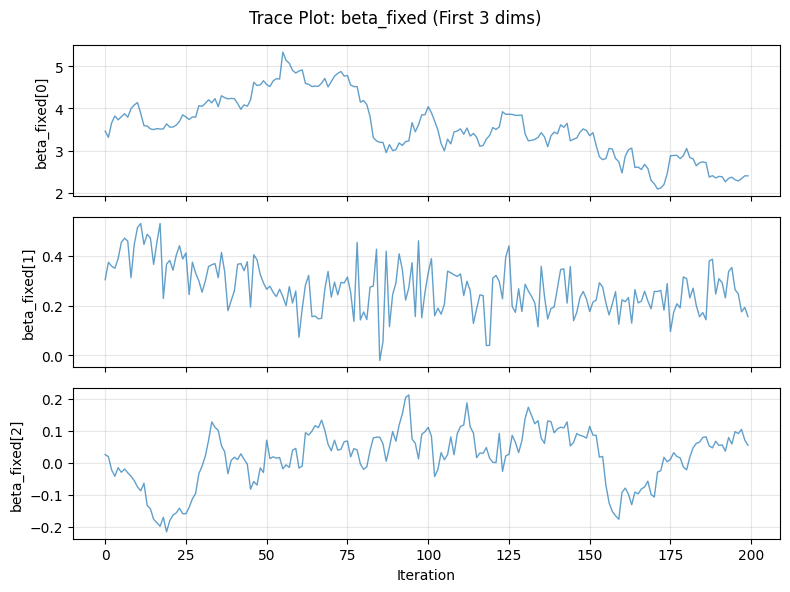

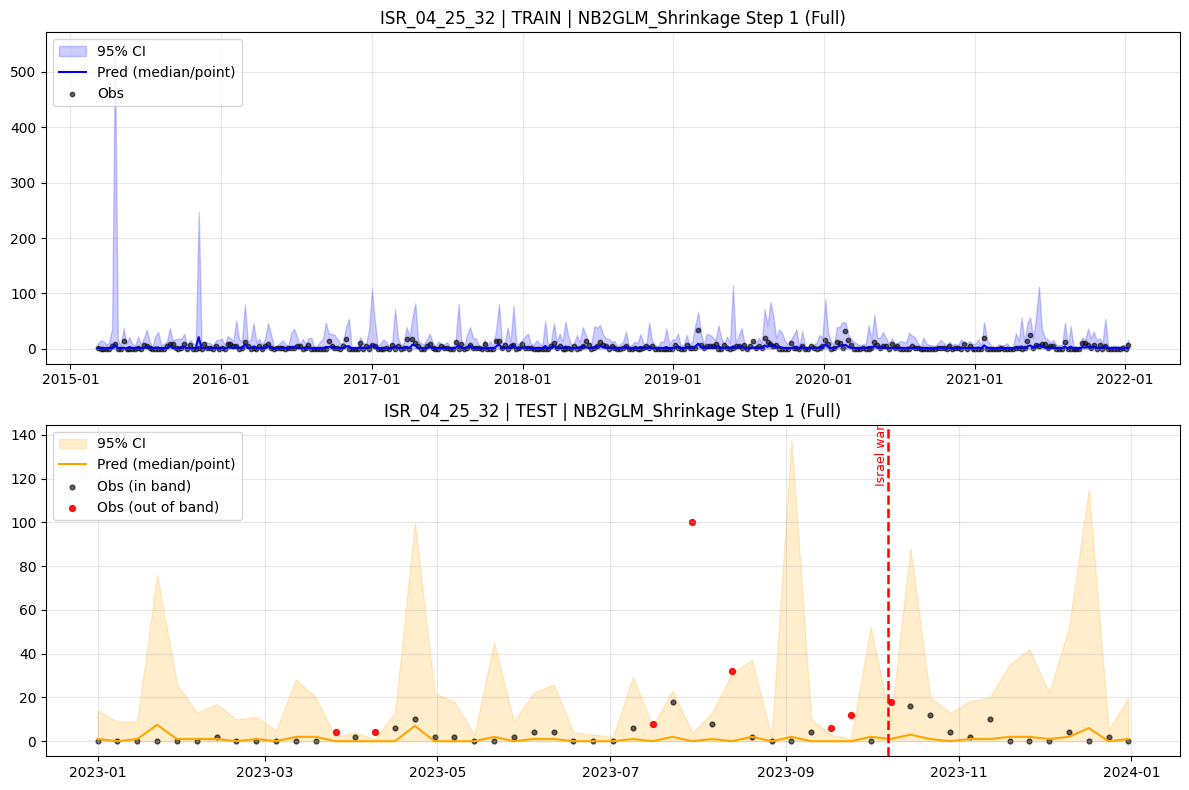

Step 1 Complete. Selected 122 variables out of 1171.
Top selected variables: ['USA_04_15_52', 'USA_04_35_42', 'USA_04_55_27', 'USA_13_25_52', 'USA_13_35_52', 'USA_13_35_57', 'USA_13_45_52', 'USA_18_35_52', 'USA_18_55_22', 'USA_18_55_42', 'USA_19_15_32', 'USA_19_25_47', 'USA_19_55_22', 'USA_19_55_27', 'RUS_04_25_22']


In [7]:
train_size = TRAIN_WEEKS_GLM - 2 

y_tr, y_te = y_aligned[:train_size], y_aligned[train_size:]
H_fixed_tr, H_fixed_te = X_fixed[:train_size], X_fixed[train_size:]
H_shrink_tr, H_shrink_te = X_shrink[:train_size], X_shrink[train_size:]
weeks_tr, weeks_te = weeks[2:TRAIN_WEEKS_GLM], weeks[TRAIN_WEEKS_GLM:]

print(f"Train samples: {len(y_tr)}, Test samples: {len(y_te)}")

ModelClass, zero_rate = choose_model(y_tr)
print(f"Target Zero Rate: {zero_rate:.2f} -> Using {ModelClass.__name__}")

model_step1 = ModelClass(u=0.5, a=0.5, tau_0=0.1, fixed_sigma=10.0)

print("Fitting Full Model (Step 1)")
model_step1.fit(
    H_fixed=H_fixed_tr, 
    H_shrink=H_shrink_tr, 
    y=y_tr, 
    num_warmup=200,
    num_samples=200
)

print("Trace plot")
plot_trace(model_step1, "beta_fixed") 

pred_tr_step1 = model_step1.predict(H_fixed_tr, H_shrink_tr)
pred_te_step1 = model_step1.predict(H_fixed_te, H_shrink_te)

plot_series_fit(
    TARGET_COL, f"{ModelClass.__name__} Step 1 (Full)",
    dates_tr=weeks_tr, y_tr=y_tr, pred_tr=pred_tr_step1,
    dates_te=weeks_te, y_te=y_te, pred_te=pred_te_step1,
    test_xlim=TEST_XLIM, event_lines=event_lines,
    q_lo=0.025, q_hi=0.975
)

#　Variable Selection
selected_indices = model_step1.get_selected_indices()
selected_vars = [shrink_names[i] for i in selected_indices]

print(f"Step 1 Complete. Selected {len(selected_indices)} variables out of {H_shrink_tr.shape[1]}.")
print("Top selected variables:", selected_vars[:15])

In [17]:
list(selected_vars)

['USA_04_15_52',
 'USA_04_35_42',
 'USA_04_55_27',
 'USA_13_25_52',
 'USA_13_35_52',
 'USA_13_35_57',
 'USA_13_45_52',
 'USA_18_35_52',
 'USA_18_55_22',
 'USA_18_55_42',
 'USA_19_15_32',
 'USA_19_25_47',
 'USA_19_55_22',
 'USA_19_55_27',
 'RUS_04_25_22',
 'RUS_04_45_32',
 'RUS_04_45_57',
 'RUS_13_15_22',
 'RUS_13_15_37',
 'RUS_13_15_47',
 'RUS_13_35_32',
 'RUS_13_45_57',
 'RUS_18_15_22',
 'RUS_18_15_42',
 'RUS_18_15_47',
 'RUS_18_15_57',
 'RUS_18_25_27',
 'RUS_18_35_27',
 'RUS_19_15_42',
 'RUS_19_25_22',
 'RUS_19_35_42',
 'RUS_19_45_32',
 'UKR_04_15_22',
 'UKR_04_55_47',
 'UKR_13_15_22',
 'UKR_13_55_32',
 'UKR_13_55_37',
 'UKR_13_55_52',
 'UKR_18_15_27',
 'UKR_18_35_52',
 'UKR_18_45_32',
 'UKR_18_45_47',
 'UKR_18_55_32',
 'UKR_18_55_57',
 'UKR_19_15_22',
 'UKR_19_15_37',
 'UKR_19_25_22',
 'UKR_19_25_47',
 'UKR_19_45_52',
 'UKR_19_55_27',
 'ISR_04_15_52',
 'ISR_04_35_42',
 'ISR_04_35_52',
 'ISR_13_15_57',
 'ISR_13_25_42',
 'ISR_13_35_32',
 'ISR_13_35_37',
 'ISR_13_45_47',
 'ISR_13_55_22

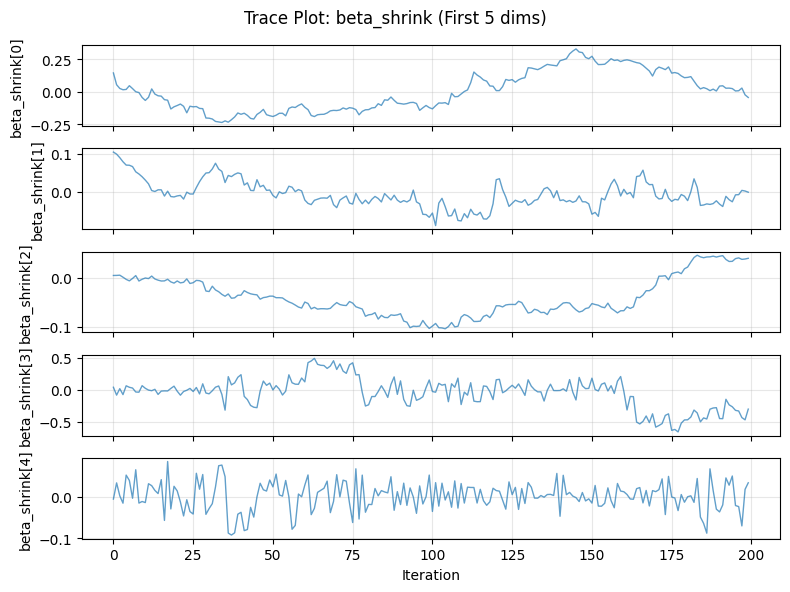

In [13]:
plot_trace(model_step1, "beta_shrink") 

In [14]:
# model_step1.fit_result.posterior_samples


--- Fitting Reduced Model (Step 2) with 122 vars ---


sample: 100%|██████████| 200/200 [00:23<00:00,  8.59it/s, 93 steps of size 2.40e-03. acc. prob=0.79]  


Generating predictions...


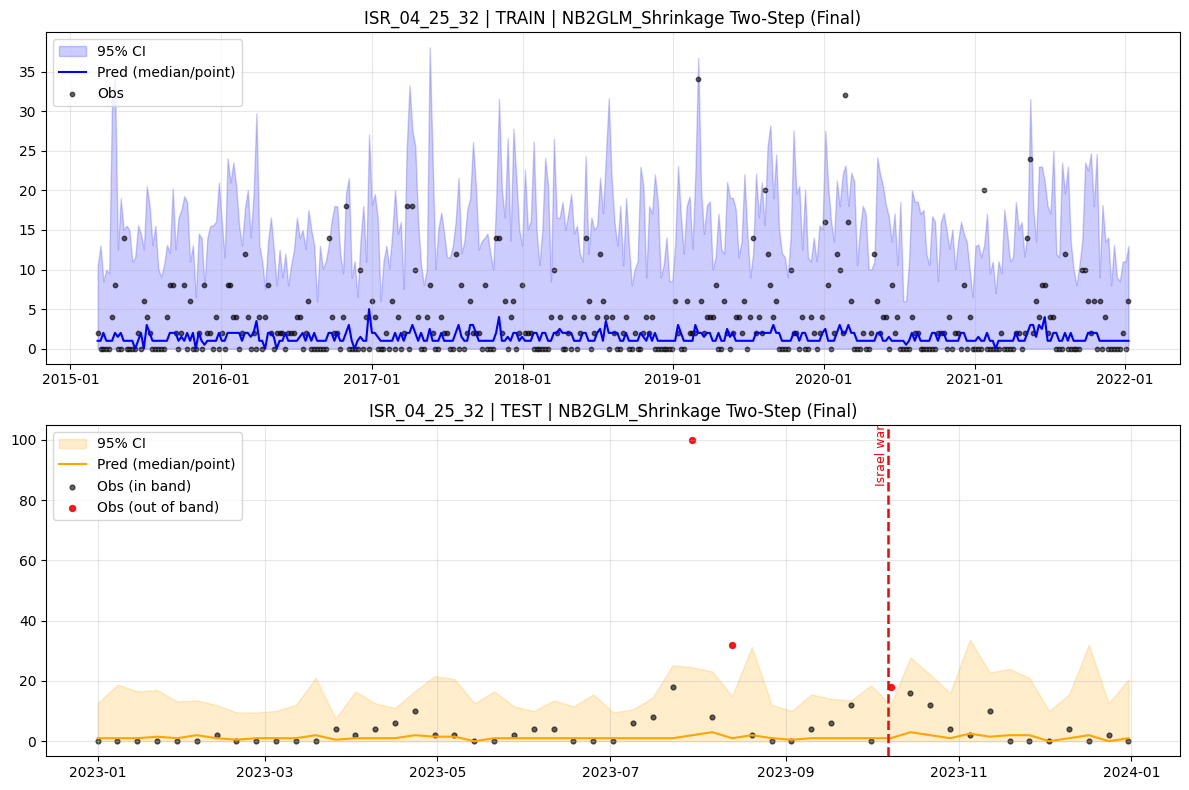

In [8]:
# Step 2 Refit
if len(selected_indices) > 0:
    H_shrink_tr_sel = H_shrink_tr[:, selected_indices]
    H_shrink_te_sel = H_shrink_te[:, selected_indices]

    # Step 2 Model: Slightly relaxed shrinkage
    model_step2 = ModelClass(u=0.5, a=0.5, tau_0=0.5, fixed_sigma=10.0)

    print(f"\n--- Fitting Reduced Model (Step 2) with {H_shrink_tr_sel.shape[1]} vars ---")
    model_step2.fit(
        H_fixed=H_fixed_tr, 
        H_shrink=H_shrink_tr_sel, 
        y=y_tr, 
        num_warmup=100, 
        num_samples=100
    )

    print("Generating predictions...")
    pred_tr = model_step2.predict(H_fixed_tr, H_shrink_tr_sel)
    pred_te = model_step2.predict(H_fixed_te, H_shrink_te_sel)

    plot_series_fit(
        TARGET_COL, f"{ModelClass.__name__} Two-Step (Final)",
        dates_tr=weeks_tr, y_tr=y_tr, pred_tr=pred_tr,
        dates_te=weeks_te, y_te=y_te, pred_te=pred_te,
        test_xlim=TEST_XLIM, event_lines=event_lines,
        q_lo=0.025, q_hi=0.975
    )
else:
    print("Skipping Step 2 because no variables were selected.")